# DVFM subject-level frailty recovery

This notebook calibrates the DVFM latent coordinate using **validation data only** and produces paper-ready figures that emphasize:

1. subject-level frailty recovery;
2. recovery among censored and uncensored subjects separately;
3. the central 98% of the distribution so a few extreme subjects do not compress the main pattern;
4. group-level calibration across frailty deciles.

The affine mapping is

\[
\widehat z_i = \alpha + \beta\,\mu_i^{\mathrm{aligned}},
\]

where \(\alpha\) and \(\beta\) are fitted on the validation split and then frozen before evaluating the test split.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

OUTPUT_DIR = Path("../outputs/semi_synthetic_support_clayton_frailty_tau05")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

VALID_PATH = OUTPUT_DIR / "latent_recovery_validation.csv"
TEST_PATH = OUTPUT_DIR / "latent_recovery_test.csv"

for path in (VALID_PATH, TEST_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run semi_synthetic_frailty.py first."
        )

valid = pd.read_csv(VALID_PATH)
test = pd.read_csv(TEST_PATH)

required = {
    "row_index",
    "event",
    "true_z",
    "learned_mu_raw",
    "learned_mu_aligned",
    "learned_std",
}
for name, frame in {"validation": valid, "test": test}.items():
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{name} file is missing columns: {sorted(missing)}")

print(f"Validation subjects: {len(valid):,}")
print(f"Test subjects:       {len(test):,}")
valid.head()

Validation subjects: 1,331
Test subjects:       1,331


,row_index,event,true_z,learned_mu_raw,learned_mu_aligned,learned_std
0,2103,0,-1.210492,4.500310,-4.500310,0.297460
1,4094,0,-0.554484,4.370755,-4.370755,0.330463
2,314,0,0.299188,1.670423,-1.670423,0.185867
3,577,1,-0.882877,1.265504,-1.265504,0.179019
4,1564,1,1.017681,-3.135178,3.135178,0.197319


## Fit the latent-scale mapping on validation data

The sign alignment has already been determined from validation data by the training script. Here we additionally learn only the **offset and scale** needed to express the DVFM latent on the standardized log-frailty scale.

In [2]:
calibrator = LinearRegression()
calibrator.fit(
    valid[["learned_mu_aligned"]],
    valid["true_z"],
)

alpha = float(calibrator.intercept_)
beta = float(calibrator.coef_[0])

for frame in (valid, test):
    frame["learned_z_calibrated"] = calibrator.predict(
        frame[["learned_mu_aligned"]]
    )
    frame["learned_z_calibrated_std"] = abs(beta) * frame["learned_std"]

print(f"Validation-derived intercept alpha: {alpha:.6f}")
print(f"Validation-derived slope beta:      {beta:.6f}")

Validation-derived intercept alpha: -0.049468
Validation-derived slope beta:      0.261347


In [3]:
def recovery_metrics(frame: pd.DataFrame, prediction_col: str) -> dict[str, float]:
    y_true = frame["true_z"].to_numpy()
    y_pred = frame[prediction_col].to_numpy()
    return {
        "pearson": float(pearsonr(y_true, y_pred).statistic),
        "spearman": float(spearmanr(y_true, y_pred).statistic),
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": float(mean_squared_error(y_true, y_pred) ** 0.5),
    }

rows = []
for split_name, frame in (("Validation", valid), ("Test", test)):
    for subgroup_name, mask in (
        ("All", np.ones(len(frame), dtype=bool)),
        ("Event observed", frame["event"].to_numpy() == 1),
        ("Censored", frame["event"].to_numpy() == 0),
    ):
        subgroup = frame.loc[mask]
        for representation, column in (
            ("Aligned, uncalibrated", "learned_mu_aligned"),
            ("Validation-calibrated", "learned_z_calibrated"),
        ):
            rows.append(
                {
                    "split": split_name,
                    "subgroup": subgroup_name,
                    "representation": representation,
                    **recovery_metrics(subgroup, column),
                    "n": len(subgroup),
                }
            )

metrics = pd.DataFrame(rows)
metrics.round(3)

,split,subgroup,representation,pearson,spearman,r2,rmse,n
0,Validation,All,"Aligned, uncalibrated",0.737,0.750,-3.800,2.233,1331
1,Validation,All,Validation-calibrated,0.737,0.750,0.542,0.690,1331
2,Validation,Event observed,"Aligned, uncalibrated",0.594,0.585,-7.568,1.875,932
3,Validation,Event observed,Validation-calibrated,0.594,0.585,0.347,0.518,932
4,Validation,Censored,"Aligned, uncalibrated",0.669,0.744,-5.371,2.903,399
5,Validation,Censored,Validation-calibrated,0.669,0.744,0.274,0.980,399
6,Test,All,"Aligned, uncalibrated",0.754,0.754,-4.831,2.237,1331
7,Test,All,Validation-calibrated,0.754,0.754,0.561,0.613,1331
8,Test,Event observed,"Aligned, uncalibrated",0.630,0.596,-9.051,1.840,932
9,Test,Event observed,Validation-calibrated,0.630,0.596,0.391,0.453,932


## Main figure: calibrated subject-level recovery

The figure is split into all subjects, event-observed subjects, and censored subjects. Each point is one subject. The axes show the **central 98%** of the joint distribution; all test subjects remain included in the reported metrics.

The censored panel is especially important because those subjects' true event times were hidden during training.

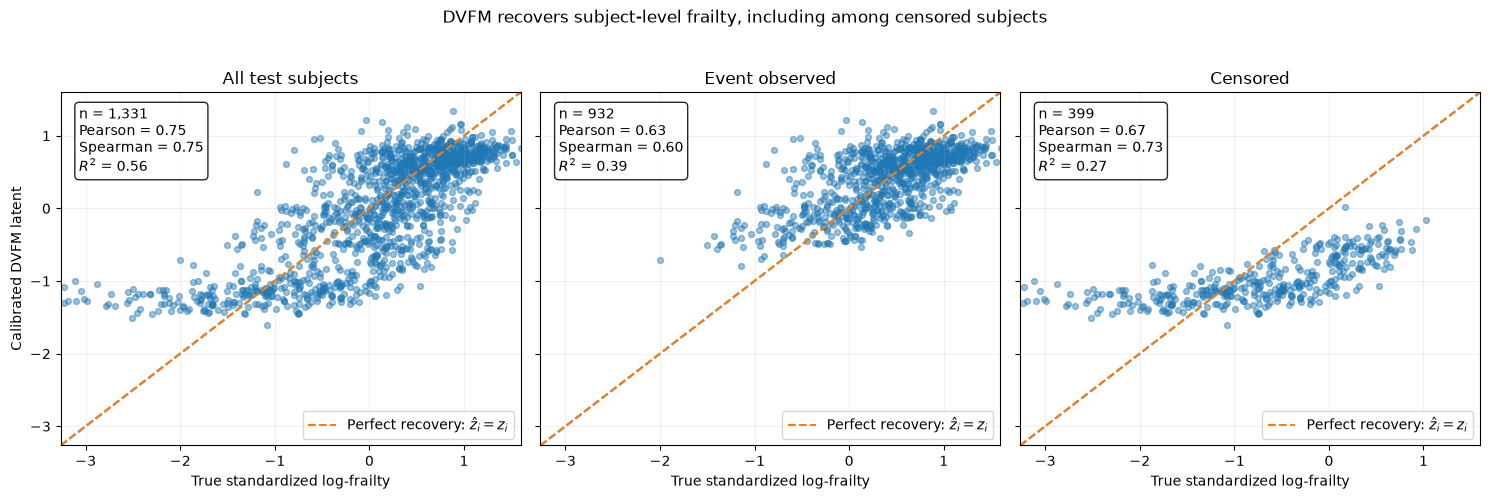

Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_calibrated_panels.png
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_calibrated_panels.pdf


In [4]:
def central_limits(
    frame: pd.DataFrame,
    x_col: str,
    y_col: str,
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> tuple[float, float]:
    x_lo, x_hi = frame[x_col].quantile([lower_q, upper_q])
    y_lo, y_hi = frame[y_col].quantile([lower_q, upper_q])
    lower = float(min(x_lo, y_lo))
    upper = float(max(x_hi, y_hi))
    padding = 0.04 * (upper - lower)
    return lower - padding, upper + padding


panels = [
    ("All test subjects", np.ones(len(test), dtype=bool)),
    ("Event observed", test["event"].to_numpy() == 1),
    ("Censored", test["event"].to_numpy() == 0),
]

limit_low, limit_high = central_limits(
    test,
    "true_z",
    "learned_z_calibrated",
)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), sharex=True, sharey=True)

for ax, (title, mask) in zip(axes, panels):
    subset = test.loc[mask]
    x = subset["true_z"].to_numpy()
    y = subset["learned_z_calibrated"].to_numpy()

    ax.scatter(x, y, alpha=0.45, s=18)
    ax.plot(
        [limit_low, limit_high],
        [limit_low, limit_high],
        linestyle="--",
        linewidth=1.5,
    )
    ax.set_xlim(limit_low, limit_high)
    ax.set_ylim(limit_low, limit_high)
    ax.set_title(title)
    ax.grid(alpha=0.18)
    
    ax.plot(
    [limit_low, limit_high],
    [limit_low, limit_high],
    linestyle="--",
    linewidth=1.5,
    label="Perfect recovery: $\\hat{z}_i=z_i$",
    )
    ax.legend()

    r = pearsonr(x, y).statistic
    rho = spearmanr(x, y).statistic
    r2 = r2_score(x, y)
    ax.text(
        0.04,
        0.96,
        f"n = {len(subset):,}\nPearson = {r:.2f}\nSpearman = {rho:.2f}\n$R^2$ = {r2:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )

axes[0].set_ylabel("Calibrated DVFM latent")
for ax in axes:
    ax.set_xlabel("True standardized log-frailty")

fig.suptitle(
    "DVFM recovers subject-level frailty, including among censored subjects",
    y=1.03,
)
fig.tight_layout()

main_png = FIGURE_DIR / "frailty_recovery_calibrated_panels.png"
main_pdf = FIGURE_DIR / "frailty_recovery_calibrated_panels.pdf"
fig.savefig(main_png, dpi=300, bbox_inches="tight")
fig.savefig(main_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {main_png}")
print(f"Saved: {main_pdf}")

### How many observations were clipped from view?

The axis limits affect only visualization. They do not remove subjects from any reported metric.

In [5]:
outside = (
    (test["true_z"] < limit_low)
    | (test["true_z"] > limit_high)
    | (test["learned_z_calibrated"] < limit_low)
    | (test["learned_z_calibrated"] > limit_high)
)

print(
    f"Subjects outside the displayed central range: "
    f"{outside.sum()} / {len(test)} ({outside.mean():.1%})"
)

Subjects outside the displayed central range: 11 / 1331 (0.8%)


## Supporting figure: uncalibrated latent coordinate

This plot shows that the DVFM posterior mean and the true frailty live on different numerical scales. The fitted line reflects association, not equality.

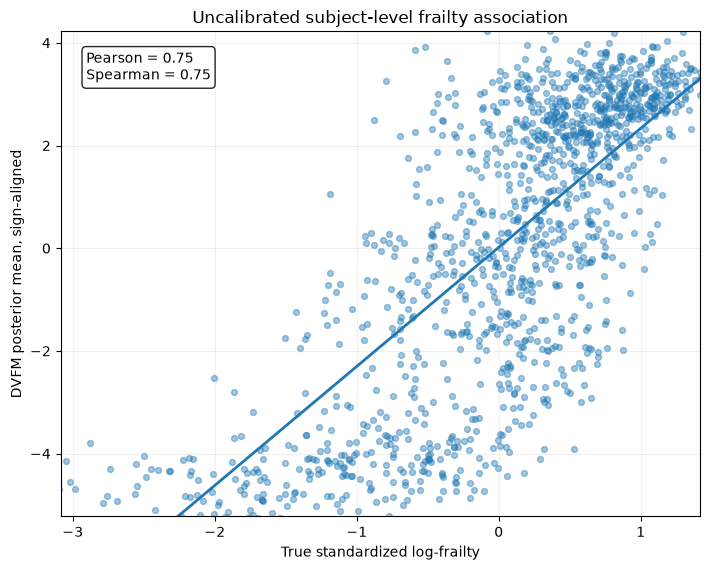

Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_uncalibrated.png
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_uncalibrated.pdf


In [6]:
x = test["true_z"].to_numpy()
y = test["learned_mu_aligned"].to_numpy()

x_low, x_high = test["true_z"].quantile([0.01, 0.99])
y_low, y_high = test["learned_mu_aligned"].quantile([0.01, 0.99])

fit = LinearRegression().fit(x.reshape(-1, 1), y)
grid = np.linspace(x_low, x_high, 200)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.scatter(x, y, alpha=0.42, s=18)
ax.plot(grid, fit.predict(grid.reshape(-1, 1)), linewidth=2)
ax.set_xlim(x_low, x_high)
ax.set_ylim(y_low, y_high)
ax.set_xlabel("True standardized log-frailty")
ax.set_ylabel("DVFM posterior mean, sign-aligned")
ax.set_title("Uncalibrated subject-level frailty association")
ax.grid(alpha=0.18)

r = pearsonr(x, y).statistic
rho = spearmanr(x, y).statistic
ax.text(
    0.04,
    0.96,
    f"Pearson = {r:.2f}\nSpearman = {rho:.2f}",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)

fig.tight_layout()

uncal_png = FIGURE_DIR / "frailty_recovery_uncalibrated.png"
uncal_pdf = FIGURE_DIR / "frailty_recovery_uncalibrated.pdf"
fig.savefig(uncal_png, dpi=300, bbox_inches="tight")
fig.savefig(uncal_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {uncal_png}")
print(f"Saved: {uncal_pdf}")

## Clean summary: calibration across frailty deciles

The scatter plot shows subject-level variation, while this decile plot shows whether DVFM recovers the frailty pattern on average. Departure from the identity line at the extremes indicates shrinkage toward the population mean.

Each point represents one tenth of the test set, grouped by true frailty.
Points below the diagonal indicate underestimation; points above indicate overestimation.

Test subjects were ranked by their true latent frailty and divided into ten equally sized groups. Each point compares the average true frailty with the average calibrated DVFM estimate within one group. The diagonal denotes perfect agreement. Deviations toward zero indicate shrinkage of extreme frailty estimates.

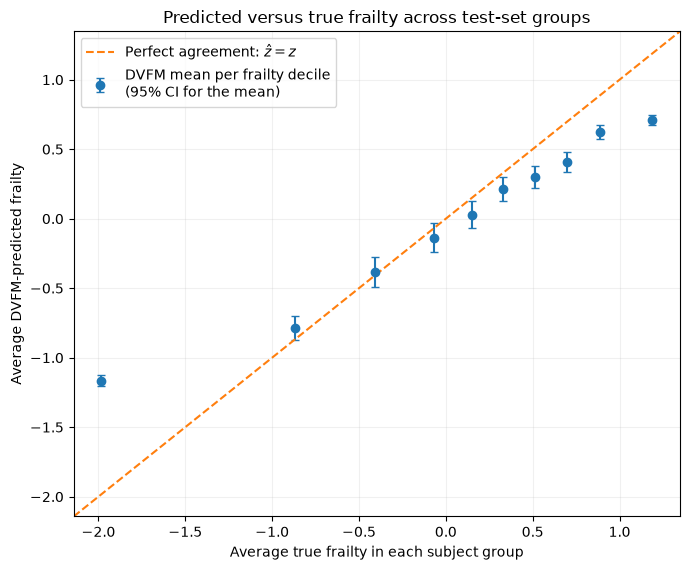

Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_deciles.png
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\figures\frailty_recovery_deciles.pdf


,true_z_mean,calibrated_mean,calibrated_sd,n,sem
0,-1.984,-1.165,0.248,134,0.021
1,-0.867,-0.785,0.505,133,0.044
2,-0.408,-0.382,0.642,133,0.056
3,-0.070,-0.136,0.611,133,0.053
4,0.151,0.029,0.568,133,0.049
5,0.332,0.214,0.512,133,0.044
6,0.515,0.300,0.476,133,0.041
7,0.696,0.405,0.427,133,0.037
8,0.887,0.627,0.295,133,0.026
9,1.189,0.710,0.209,133,0.018


In [7]:
test_with_bins = test.copy()
test_with_bins["true_z_decile"] = pd.qcut(
    test_with_bins["true_z"],
    q=10,
    duplicates="drop",
)

binned = (
    test_with_bins
    .groupby("true_z_decile", observed=True)
    .agg(
        true_z_mean=("true_z", "mean"),
        calibrated_mean=("learned_z_calibrated", "mean"),
        calibrated_sd=("learned_z_calibrated", "std"),
        n=("true_z", "size"),
    )
    .reset_index(drop=True)
)

# Standard error of the mean calibrated latent within each decile.
binned["sem"] = binned["calibrated_sd"] / np.sqrt(binned["n"])

lower = float(
    min(
        binned["true_z_mean"].min(),
        binned["calibrated_mean"].min(),
    )
)
upper = float(
    max(
        binned["true_z_mean"].max(),
        binned["calibrated_mean"].max(),
    )
)
padding = 0.05 * (upper - lower)
lower -= padding
upper += padding

fig, ax = plt.subplots(figsize=(7.0, 5.8))

ax.errorbar(
    binned["true_z_mean"],
    binned["calibrated_mean"],
    yerr=1.96 * binned["sem"],
    fmt="o",
    capsize=3,
    label="DVFM mean per frailty decile\n(95% CI for the mean)",
)

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    label=r"Perfect agreement: $\hat{z}=z$",
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Average true frailty in each subject group")
ax.set_ylabel("Average DVFM-predicted frailty")
ax.set_title("Predicted versus true frailty across test-set groups")
ax.grid(alpha=0.18)
ax.legend(frameon=True, loc="upper left")

fig.tight_layout()

decile_png = FIGURE_DIR / "frailty_recovery_deciles.png"
decile_pdf = FIGURE_DIR / "frailty_recovery_deciles.pdf"

fig.savefig(decile_png, dpi=300, bbox_inches="tight")
fig.savefig(decile_pdf, bbox_inches="tight")
plt.show()

print(f"Saved: {decile_png}")
print(f"Saved: {decile_pdf}")

binned.round(3)

## Suggested paper-facing summary

The primary evidence should be the calibrated three-panel figure and the following held-out test statistics. Correlation measures ordering and association; calibrated \(R^2\) and RMSE measure agreement on the true frailty scale.

In [8]:
paper_metrics = (
    metrics[
        (metrics["split"] == "Test")
        & (metrics["representation"] == "Validation-calibrated")
    ]
    .loc[:, ["subgroup", "n", "pearson", "spearman", "r2", "rmse"]]
    .reset_index(drop=True)
)

paper_metrics.round(3)

,subgroup,n,pearson,spearman,r2,rmse
0,All,1331,0.754,0.754,0.561,0.613
1,Event observed,932,0.630,0.596,0.391,0.453
2,Censored,399,0.668,0.729,0.270,0.881


## Optional diagnostic: posterior interval coverage

This is intentionally kept as a secondary diagnostic rather than a main result. An affine mapping of posterior means and standard deviations does not guarantee calibrated Bayesian uncertainty.

In [9]:
test["calibrated_lower_95"] = (
    test["learned_z_calibrated"]
    - 1.96 * test["learned_z_calibrated_std"]
)
test["calibrated_upper_95"] = (
    test["learned_z_calibrated"]
    + 1.96 * test["learned_z_calibrated_std"]
)
test["covered_95"] = (
    (test["true_z"] >= test["calibrated_lower_95"])
    & (test["true_z"] <= test["calibrated_upper_95"])
)
test["interval_width"] = (
    test["calibrated_upper_95"] - test["calibrated_lower_95"]
)

coverage = (
    test.assign(
        status=np.where(test["event"] == 1, "Event observed", "Censored")
    )
    .groupby("status")
    .agg(
        coverage_95=("covered_95", "mean"),
        mean_interval_width=("interval_width", "mean"),
        n=("covered_95", "size"),
    )
)

overall = pd.DataFrame(
    {
        "coverage_95": [test["covered_95"].mean()],
        "mean_interval_width": [test["interval_width"].mean()],
        "n": [len(test)],
    },
    index=["All"],
)

pd.concat([overall, coverage]).round(3)

,coverage_95,mean_interval_width,n
All,0.201,0.268,1331
Censored,0.145,0.288,399
Event observed,0.224,0.260,932


## Save calibrated outputs and summary metrics

In [10]:
valid_out = OUTPUT_DIR / "latent_recovery_validation_calibrated.csv"
test_out = OUTPUT_DIR / "latent_recovery_test_calibrated.csv"
metrics_out = OUTPUT_DIR / "latent_calibration_metrics.csv"
paper_metrics_out = OUTPUT_DIR / "latent_calibration_paper_metrics.csv"

valid.to_csv(valid_out, index=False)
test.to_csv(test_out, index=False)
metrics.to_csv(metrics_out, index=False)
paper_metrics.to_csv(paper_metrics_out, index=False)

print(f"Saved: {valid_out}")
print(f"Saved: {test_out}")
print(f"Saved: {metrics_out}")
print(f"Saved: {paper_metrics_out}")

Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_recovery_validation_calibrated.csv
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_recovery_test_calibrated.csv
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_calibration_metrics.csv
Saved: ..\outputs\semi_synthetic_support_clayton_frailty_tau05\latent_calibration_paper_metrics.csv
